# 1) Cài đặt môi trường

In [ ]:
import os
import zipfile
import shutil
import tensorflow as tf
import numpy as np
import random
from google.colab import drive

# 1. Cài đặt Seed & Check GPU
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# 2. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# =================================================================
# PHẦN QUAN TRỌNG: COPY ZIP TỪ DRIVE -> COLAB -> GIẢI NÉN
# =================================================================

# Đường dẫn file ZIP nằm trên Google Drive của bạn
# Hãy sửa lại đúng đường dẫn nơi bạn để file zip
DRIVE_ZIP_PATH = "/content/drive/MyDrive/CS406_Project/Harvesting_Dataset_D2.zip"

# Đường dẫn thư mục sẽ giải nén tại máy ảo Colab (Local)
LOCAL_EXTRACT_DIR = "/content/dataset_unzipped"

if not os.path.exists(DRIVE_ZIP_PATH):
    print(f"❌ LỖI: Không tìm thấy file zip tại: {DRIVE_ZIP_PATH}")
    print("👉 Hãy upload file zip lên Drive và sửa lại đường dẫn trong code.")
else:
    # Nếu chưa giải nén thì mới làm (để tránh làm lại nếu chạy lại cell)
    if not os.path.exists(LOCAL_EXTRACT_DIR):
        print(f"⏳ Đang copy file ZIP từ Drive xuống Colab (nhanh hơn copy folder)...")
        # Copy file zip về /content/temp.zip
        local_zip_path = "/content/temp.zip"
        shutil.copy(DRIVE_ZIP_PATH, local_zip_path)

        print(f"⏳ Đang giải nén dữ liệu...")
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(LOCAL_EXTRACT_DIR)

        # Xóa file zip cho nhẹ máy
        os.remove(local_zip_path)
        print("✅ Đã giải nén xong!")
    else:
        print("✅ Dữ liệu đã được giải nén sẵn.")

# =================================================================
# TỰ ĐỘNG TÌM DATA_DIR SAU KHI GIẢI NÉN
# =================================================================

# Thường khi giải nén, nó sẽ tạo ra thư mục con.
# Đoạn này giúp tìm đúng folder chứa ảnh (Cut/Keep)
target_folders = ["Cut", "Keep", "cut", "keep"] # Tên các folder class của bạn
DATA_DIR = LOCAL_EXTRACT_DIR

# Duyệt tìm xem folder chứa ảnh nằm sâu ở đâu
found = False
for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
    # Nếu trong thư mục hiện tại có chứa folder Cut hoặc Keep
    if any(f in dirs for f in target_folders):
        DATA_DIR = root
        found = True
        break

print(f"📂 DATA_DIR đang trỏ tới: {DATA_DIR}")
print("Subfolders:", os.listdir(DATA_DIR))

# Nếu code in ra đúng folder chứa Cut/Keep thì OK.
# Nếu không, bạn cần chỉnh tay biến DATA_DIR

TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive
❌ LỖI: Không tìm thấy file zip tại: /content/drive/MyDrive/CS406_Project/Harvesting_Dataset_D2.zip
👉 Hãy upload file zip lên Drive và sửa lại đường dẫn trong code.
📂 DATA_DIR đang trỏ tới: /content/dataset_unzipped


FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset_unzipped'

# 2) Tiền xử lý dữ liệu

In [ ]:
# ==========================================
# 2) TIỀN XỬ LÝ DỮ LIỆU (ĐÃ SỬA LỖI SHUFFLE)
# ==========================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

# Định nghĩa tham số
IMG_SIZE = (256, 256)
BATCH = 32

# --- Tạo Generator ---
train_aug = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    fill_mode='nearest',
    validation_split=0.30
)

no_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.30
)

print(f"\n--- Loading Data from: {DATA_DIR} ---")

# Load tập Train
train_it = train_aug.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=SEED
)

# Load tập tạm (để chia Val/Test)
# Lưu ý: Vẫn để shuffle=False ở đây để lấy đúng thứ tự file và nhãn
temp_it = no_aug.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=SEED
)

# --- XỬ LÝ CHIA VAL/TEST (Đã sửa lỗi) ---
temp_paths = np.array(temp_it.filepaths)
temp_labels = np.array(temp_it.classes)

# 1. Tạo danh sách chỉ số và TRỘN NGẪU NHIÊN (Đây là bước fix lỗi)
indices = np.arange(len(temp_paths))
np.random.shuffle(indices)

# 2. Sắp xếp lại dữ liệu theo thứ tự đã trộn
temp_paths = temp_paths[indices]
temp_labels = temp_labels[indices]

# 3. Chia đôi 50-50 (tương đương 15% Val - 15% Test của tổng dataset)
mid = len(temp_paths) // 2
val_paths, val_labels = temp_paths[:mid], temp_labels[:mid]
test_paths, test_labels = temp_paths[mid:], temp_labels[mid:]

print("-" * 30)
print(f"Train size: {train_it.samples}")
print(f"Val size  : {len(val_paths)} (Class 0: {np.sum(val_labels==0)}, Class 1: {np.sum(val_labels==1)})")
print(f"Test size : {len(test_paths)} (Class 0: {np.sum(test_labels==0)}, Class 1: {np.sum(test_labels==1)})")
print("-" * 30)

# --- Tính Class Weights ---
train_labels = train_it.classes
try:
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"⚖️ Class Weights: {class_weights_dict}")
except:
    print("⚠️ Không thể tính Class Weights (có thể do lỗi version), sẽ bỏ qua bước này.")
    class_weights_dict = None

# --- Hàm tạo tf.data ---
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return img, label

def make_ds(paths, labels, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print("Đang tạo tf.data cho Validation và Test...")
val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)
print("✅ Hoàn tất tiền xử lý (Dữ liệu đã được trộn đều)!")

# 3) Huấn luyện mô hình

In [ ]:
# ==========================================
# 3) HUẤN LUYỆN MÔ HÌNH (Full Code)
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import DenseNet121

# Hàm xây dựng model
def build_model():
    # Tải pre-trained model DenseNet121
    base = DenseNet121(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # Đóng băng (Freeze) các lớp dưới để giữ lại kiến thức imagenet

    # Xây dựng phần đầu (Head) mới cho bài toán của mình
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x) # Giúp train ổn định hơn
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)         # Chống học vẹt (overfitting)
    out = layers.Dense(1, activation="sigmoid")(x) # Output 1 node (0 hoặc 1)

    model = models.Model(inp, out)

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc"), tf.keras.metrics.AUC(name="auc")]
    )
    return model

# Khởi tạo model
print("Đang xây dựng model DenseNet121...")
model = build_model()
model.summary()

# Thiết lập Callbacks (Dừng sớm nếu không tốt hơn)
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Bắt đầu huấn luyện
print("\n🚀 Bắt đầu huấn luyện...")
history = model.fit(
    train_it,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict  # Dùng biến này từ phần trước để cân bằng dữ liệu
)

🏗️ Đang xây dựng model DenseNet121...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)


🚀 Bắt đầu huấn luyện...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - acc: 0.6453 - auc: 0.7259 - loss: 0.6344 - val_acc: 0.5746 - val_auc: 0.7773 - val_loss: 0.7956 - learning_rate: 0.0010
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.8321 - auc: 0.9177 - loss: 0.3739 - val_acc: 0.6119 - val_auc: 0.7983 - val_loss: 0.7553 - learning_rate: 0.0010
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.8485 - auc: 0.9228 - loss: 0.3533 - val_acc: 0.7413 - val_auc: 0.8559 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.8708 - auc: 0.9420 - loss: 0.3069 - val_acc: 0.7562 - val_auc: 0.8569 - val_loss: 0.5434 - learning_rate: 0.0010
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.8665 - auc: 0.9367 - loss: 0.3230 - val_acc: 0.7861 - val_auc: 0.8671 - val_loss: 0.5256 - learning_rate: 0.0010
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - acc: 0.8648 - auc: 0.9448 - loss: 0.2992 - val_acc: 0.7761 - val_auc: 0.8541

# 4) Đánh giá và trực quan hóa

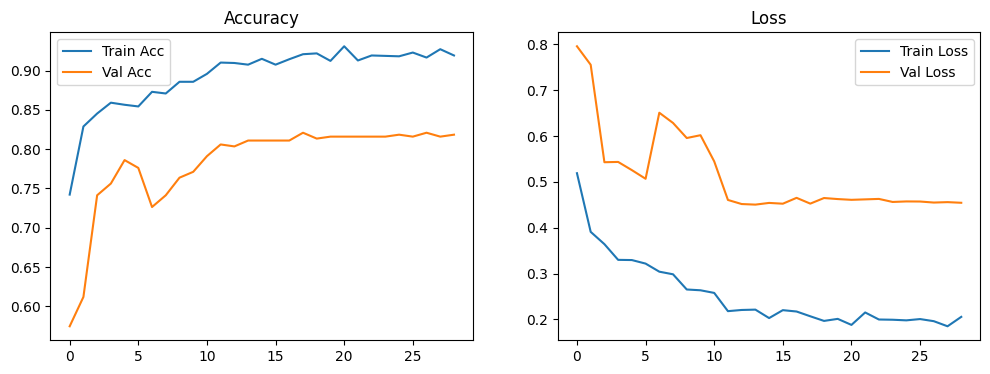

In [ ]:
# ==========================================
# 4) ĐÁNH GIÁ & TRỰC QUAN HÓA
# ==========================================
import matplotlib.pyplot as plt

# Vẽ biểu đồ
def plot_history(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

# 5) Fine-tune threshold and test


--- Đang tìm Threshold tối ưu trên tập Valid ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step

🏆 BEST THRESHOLD (Validation):
{'thr': np.float64(0.25), 'precision': np.float64(0.8240343347604119), 'recall': np.float64(0.8533333333295408), 'f1': np.float64(0.8384279470947446), 'acc': np.float64(0.8159203980079206), 'specificity': np.float64(0.768361581916563)}

--- Đánh giá trên tập TEST với Threshold đã chọn ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step
Chosen Threshold: 0.2500
Test Accuracy   : 0.8085
Test F1-Score   : 0.8412
Test Precision  : 0.8226
Test Recall     : 0.8608


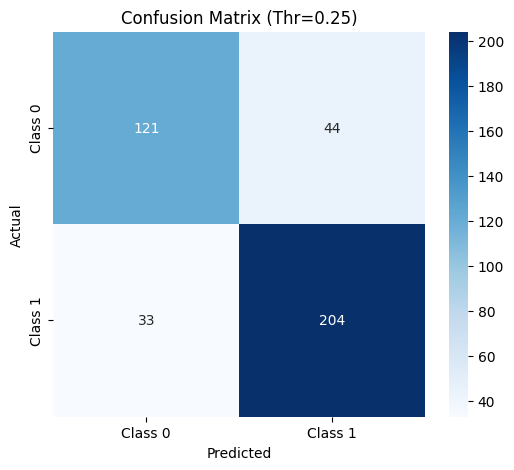

In [ ]:
# ==========================================
# 5) FINE-TUNING THRESHOLD & TEST
# ==========================================

def metrics_at_thr(y_true, y_prob, thr):
    y_hat = (y_prob >= thr).astype(int)
    tp = np.sum((y_hat==1) & (y_true==1))
    tn = np.sum((y_hat==0) & (y_true==0))
    fp = np.sum((y_hat==1) & (y_true==0))
    fn = np.sum((y_hat==0) & (y_true==1))

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    acc       = (tp + tn) / (tp + tn + fp + fn + 1e-9)
    # specificity = tn / (tn + fp + 1e-9)
    return precision, recall, f1, acc

print("\n--- Đang tìm Threshold tối ưu trên tập Valid ---")
val_probs = model.predict(val_ds, verbose=1).ravel()
val_y = val_labels.astype(int)

ths = np.linspace(0.1, 0.9, 81)
best = None

for t in ths:
    prec, rec, f1, acc, spe = metrics_at_thr(val_y, val_probs, t)
    # Ưu tiên F1 Score
    if best is None or f1 > best["f1"]:
        best = {"thr": t, "precision": prec, "recall": rec, "f1": f1, "acc": acc, "specificity": spe}

print("\n🏆 BEST THRESHOLD (Validation):")
print(best)

# --- ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\n--- Đánh giá trên tập TEST với Threshold đã chọn ---")
test_probs = model.predict(test_ds, verbose=1).ravel()
test_y = test_labels.astype(int)

thr = best["thr"]
prec, rec, f1, acc, spe = metrics_at_thr(test_y, test_probs, thr)

print(f"Chosen Threshold: {thr:.4f}")
print(f"Test Accuracy   : {acc:.4f}")
print(f"Test F1-Score   : {f1:.4f}")
print(f"Test Precision  : {prec:.4f}")
print(f"Test Recall     : {rec:.4f}")

# Confusion Matrix
y_hat_test = (test_probs >= thr).astype(int)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_y, y_hat_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Thr={thr:.2f})')
plt.show()


# 6) Lưu mô hình

In [ ]:
# ==========================================
# 6) LƯU MODEL
# ==========================================
# SAVE_PATH = "/content/drive/MyDrive/CS406_Project/densenet121_d2_cut_keep_optimized.keras"
# model.save(SAVE_PATH)
# print(f"✅ Model đã lưu tại: {SAVE_PATH}")

✅ Model đã lưu tại: /content/drive/MyDrive/CS406_Project/densenet121_d2_cut_keep_optimized.keras


$\frac{TP + TN}{TP + TN + FP + FN}$

$\frac{TP}{TP + FP}$

$\frac{TP}{TP + FN}$

$2 \times \frac{Precision \times Recall}{Precision + Recall}$